# Scan processing

Task: split scan in left page and right page

1. Tried dividing images in two equally-sized halves with the Pythons Pillow library but the divisions are not at 50% so this produced many incorrect splits
2. Next, tried the [scantailor tool](https://github.com/vigri/scantailor-advanced) (tip from Claude) but this required a lot of manual work, The tool managed to get about 60% of the splits right but next refused to save the result(?!) before manual margin processing was done.
3. Finally, wrote Python code to split pages based on a very dark vertical bar preceded or followed by a very light bar
   

## 1. Split images in two equally-sized halves

In [14]:
from PIL import Image
import os

In [15]:
IMG_DIR = "../data/scan-sample-100"

img_file = os.listdir(IMG_DIR)[0]

In [16]:
img = Image.open(os.path.join(IMG_DIR, img_file))
width, height = img.size
img_left = img.crop((0, 0, int(width / 2), height))
img_right = img.crop((int(width / 2), 0, width, height))

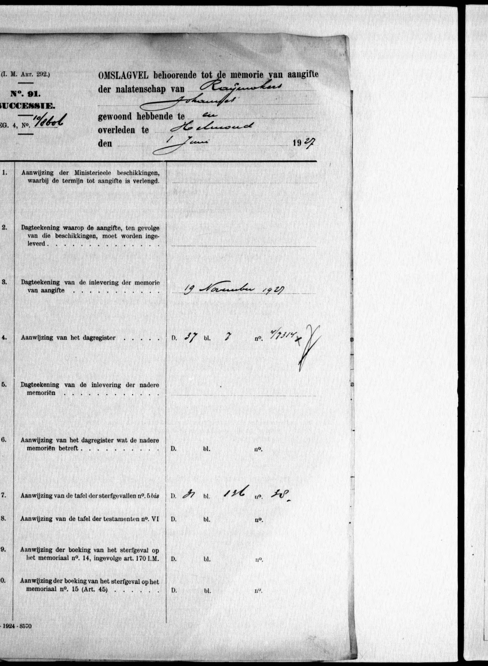

In [24]:
preview = img_right.copy()
preview.thumbnail((500, 666))
preview

The image is not cerrectly split: at the top left, text from the right page is missing

## 2. Split with software scantailor

Tests performed somewhere else

## 3. Split based on dark vertical bar and close light vertical bar

In [1]:
from PIL import Image
import numpy as np
import os
import regex
import matplotlib.pyplot as plt

In [2]:
def find_split_point(img, bar_width=5):
    img_gray = img.convert("L")
    img_pixels = np.array(img_gray)
    
    width = img_pixels.shape[1]
    split_x_min = int(width * 0.40)
    split_x_max = int(width * 0.60)
    max_bar_distance = 20
    darkness_scores = []

    for x in range(split_x_min - max_bar_distance, split_x_max - bar_width + max_bar_distance):
        bar = img_pixels[:, x: x + bar_width]
        darkness_scores.append(bar.mean())

    # use largest darkness delta
    deltas = [np.max(darkness_scores[x - max_bar_distance: x + max_bar_distance]) - darkness_scores[x] 
              for x in range(max_bar_distance, len(darkness_scores) - max_bar_distance)]
    split_x = split_x_min + int(np.argmax(deltas) + bar_width / 2)
    
    return split_x

In [3]:
def show_images(img_left, img_right):
    width_ratios = [img_left.width, img_right.width]
    fig, (ax1, ax2) = plt.subplots(1, 2, 
                                   figsize=(4, 6), 
                                   gridspec_kw={"width_ratios": width_ratios})
    ax1.imshow(img_left, cmap="gray")
    ax2.imshow(img_right, cmap="gray")
    ax1.axis("off") 
    ax2.axis("off")
    plt.show()

Original test directory with scans: ../data/scan-sample-100

The estimated accuracy of the process was 85-90%.

In [4]:
def process_dir(img_dir, split_x_fraction=None):
    """Split all scans in img_dir, store results the subdirectory 'out'"""
    other_file_count = 0
    os.makedirs(os.path.join(img_dir, "out"), exist_ok=True)
    for index, img_file in enumerate(sorted(os.listdir(img_dir))):
        if not regex.search("jpg$", img_file):
            other_file_count += 1
        else:
            img = Image.open(os.path.join(img_dir, img_file))
            split_x = find_split_point(img, bar_width=5) if not split_x_fraction else int(split_x_fraction * img.width)
            print(index + 1 - other_file_count, split_x, img.width, round(split_x / img.width, 2))

            img_left = img.crop((0, 0, split_x, img.height))
            img_right = img.crop((split_x, 0, img.width, img.height))
            img_right.save(os.path.join(img_dir, "out", regex.sub(".jpg$", f"_R_{int(100 * round(split_x / img.width, 2))}.jpg", img_file)))
            img_left.save(os.path.join(img_dir, "out", regex.sub(".jpg$", f"_L_{int(100 * round(split_x / img.width, 2))}.jpg", img_file)))
    show_images(img_left, img_right)

1 1973 4394 0.45
2 2007 4394 0.46
3 1979 4394 0.45
4 2061 4394 0.47


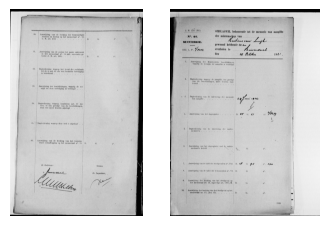

In [6]:
process_dir("images/annotate1", split_x_fraction=None)